TorchGeo. Designed for images with multispectral bands. Reprojection, resampling, rasterrising vector datasets. 
Started 4 yars ago, as internship project at AI for good microsoft instutute. 

Missing complete timeseries support. Sitz ecosystem. 1D , a point source, 2D is covered. 3D. Damage by distaster. change distection before and after, Crop mapping in the time dimensions, and spatial. 4d medium range forcasting (x, y, z (altitude) and time. )

want to seperatly index space or time at both the same time. Archery, shaple, geopandas. Sweitched to geopandas :o rasterio. Had to rwrite rasterio for data loading- wraps around gdal. but, alot of things want to read are not in that list, netcdf, looking at xarray. looking to replace rastrio with rioxarray. looking at replacing fiona with geopandas. 


Adding change detection changer. 

what is a geosampler. 

GeoAI

PyTorch
Code for processing data samples can get messy and hard to maintain; we ideally want our dataset code to be decoupled from our model training code for better readability and modularity. PyTorch provides two data primitives: torch.utils.data.DataLoader and torch.utils.data.Dataset that allow you to use pre-loaded datasets as well as your own data. Dataset stores the samples and their corresponding labels, and DataLoader wraps an iterable around the Dataset to enable easy access to the samples.

Dataloader passes an iterable around dataset. 

Bigearth net. Trainlinear probing on foudational models, but linear probling on other model

Bigearth net. Use your own datasets to tune foundational models. Linear programming vs fine tuning.  

Linear probing- only updating the head. Fine tuning can be wrose on out-of-distribution

presto embedding, major tom embeddings. do embeddigns include era5 ? no. it should though. Low dimensional representaiton of an area. Presto have an MIT lisence. 

Pytorch example. 

Let ID be a python stringthat identifies a given sample of the dataset. 
Create a dictionary call ['partition'] which has partiion['train'] and partition['validation']

In [ ]:
from torchgeo.models import RCF

In [ ]:
import os
import tempfile

import kornia.augmentation as K
import torch
from torch import nn, optim
from torch.utils.data import DataLoader

In [7]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# Load your arrays
X = np.load("X_patches.npy")  # shape: (N, C, H, W)
Y = np.load("y_patches.npy")  # shape: (N, H, W)

# Convert to channels-first if needed
if X.shape[-1] <= 20:  # assume last dim is channels
    X = np.transpose(X, (0, 3, 1, 2))  # -> (N, C, H, W)

print("X shape after transpose:", X.shape) 

print("X shape:", X.shape)
print("Y shape:", Y.shape)

# Custom dataset
class NumpySegmentationDataset(Dataset):
    def __init__(self, x, y, transform=None):
        self.x = torch.from_numpy(x).float()
        self.y = torch.from_numpy(y).long()
        self.transform = transform

    def __len__(self): # allows getting the len. why can't you just call len?
        return len(self.x)

    def __getitem__(self, idx): #allows for indexing later on. 
        x = self.x[idx]
        y = self.y[idx]
        if self.transform:
            x, y = self.transform(x, y)
        return x, y

dataset = NumpySegmentationDataset(X, Y)
train_loader = DataLoader(dataset, batch_size=16, shuffle=True)


X shape after transpose: (606, 3, 224, 224)
X shape: (606, 3, 224, 224)
Y shape: (606, 224, 224)


In [9]:
import os
os.path.getsize("X_patches.npy")

91220096

In [4]:
import torch.nn as nn
from torchvision.models.segmentation import deeplabv3_resnet50

# Pretrained DeepLabV3
model = deeplabv3_resnet50(pretrained=True)

# Adjust classifier for your number of classes
num_classes = len(torch.unique(torch.from_numpy(Y)))
model.classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)


c:\Users\HannahNevill\sims\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\HannahNevill\sims\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss(ignore_index = 255)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(5):  # adjust epochs
    model.train()
    epoch_loss = 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)["out"]  # DeepLab outputs dict
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {epoch_loss/len(train_loader):.4f}")


KeyboardInterrupt: 

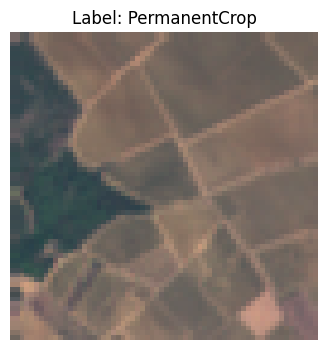

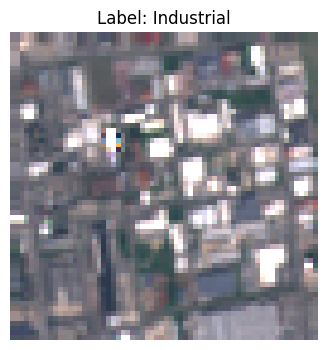

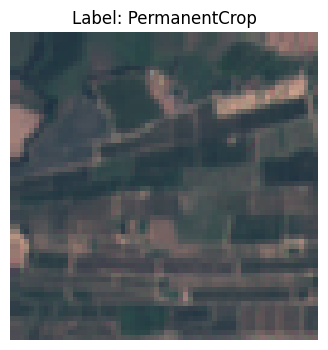

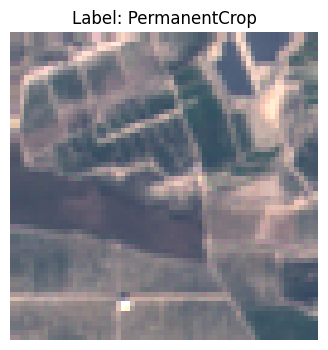

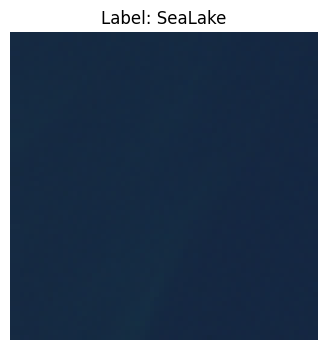

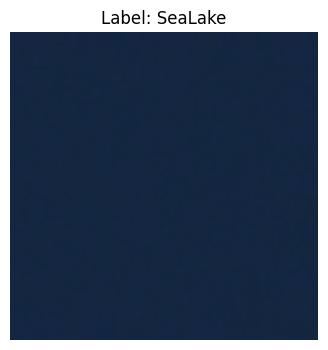

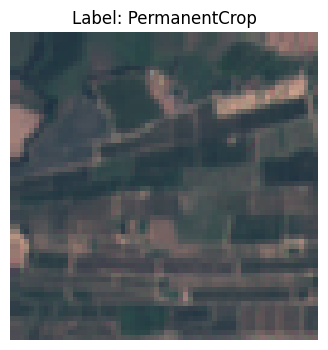

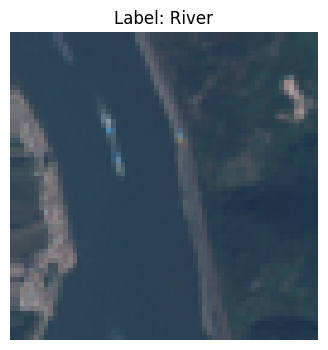

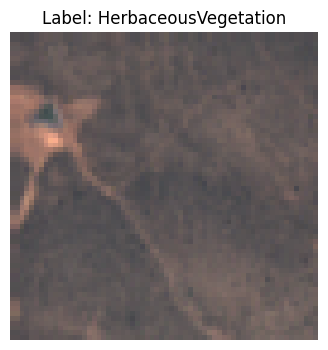

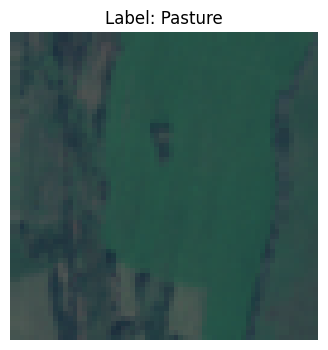

In [6]:
import numpy
import os

root = os.path.join(tempfile.gettempdir(), 'eurosat100')
dataset = EuroSAT100(root, download=True)

for i in torch.randint(len(dataset), (10,)):
    sample = dataset[i]
    dataset.plot(sample)

In [9]:
train_dataset = EuroSAT100(root, download = True, split='train')
val_dataset = EuroSAT100(root, download = True, split='val')
test_dataset = EuroSAT100(root, download = True, split='test')

100%|██████████| 382/382 [00:00<?, ?B/s] 


In [18]:
batch_size = 10

train_dataloader = DataLoader(train_dataset, batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size, shuffle=False)

One hot encoding is a method for converting categorical variables into binary format. 

Transforms. Two types of trasnforms users may want to apply to their data:
    Preprocessing: required to make data 'ML-ready'
    Data Augmentation: designed to artificially inflate size of data set.

Below we initialise transofrms from the Kornia library.

In [24]:
preprocess = K.Normalize(0, 10000)
augment = K.ImageSequential(K.RandomHorizontalFlip(), K.RandomVerticalFlip())
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=1e-2)

In [ ]:
#RestNet18 model with weights pre-trained on sentinel 2 data.
model = resnet18(ResNet18_Weights.SENTINEL2_ALL_MOCO)

Downloading: "https://hf.co/torchgeo/resnet18_sentinel2_all_moco/resolve/5b8cddc9a14f3844350b7f40b85bcd32aed75918/resnet18_sentinel2_all_moco-59bfdff9.pth" to C:\Users\HannahNevill/.cache\torch\hub\checkpoints\resnet18_sentinel2_all_moco-59bfdff9.pth


100%|██████████| 42.8M/42.8M [00:04<00:00, 9.24MB/s]


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device) #because deep learning is alot of linear algerbra, its very easy to parrelelise. 

In [ ]:
def train(dataloader):
    model.train()
    total_loss = 0
    for batch in dataloader:
        x = batch['image'].to(device) # brings image into memory.
        y = batch['label'].to(device)
        x = preprocess(x)
        x = augment(x)

        # Forward pass
        y_hat = model(x)
        loss = loss_fn(y_hat, y)
        total_loss += loss.item()

        # Backward pass
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    print(f'Loss: {total_loss:.2f}')

In [22]:
def evaluate(dataloader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for batch in dataloader:
            x = batch['image'].to(device)
            y = batch['label'].to(device)
            x = preprocess(x)

            # Forward pass
            y_hat = model(x)
            correct += (y_hat.argmax(1) == y).type(torch.float).sum().item()

    correct /= len(dataloader.dataset)
    print(f'Accuracy: {correct:.0%}')

In [16]:
epochs = 10

In [25]:
for epoch in range(epochs):
    print(f'Epoch: {epoch}')
    train(train_dataloader)
    evaluate(val_dataloader)

Epoch: 0
Loss: 41.33
Accuracy: 0%
Epoch: 1
Loss: 41.20
Accuracy: 0%
Epoch: 2
Loss: 41.04
Accuracy: 5%
Epoch: 3
Loss: 40.87
Accuracy: 15%
Epoch: 4
Loss: 40.82
Accuracy: 15%
Epoch: 5
Loss: 40.60
Accuracy: 20%
Epoch: 6
Loss: 40.51
Accuracy: 20%
Epoch: 7
Loss: 40.17
Accuracy: 30%
Epoch: 8
Loss: 40.12
Accuracy: 35%
Epoch: 9
Loss: 39.87
Accuracy: 35%


In [26]:
evaluate(test_dataloader)

Accuracy: 30%


Preprocess to ImageNet mean and standard deviation. 

In [28]:
all_models = list_models()

NameError: name 'list_models' is not defined

Models and pre-trained weight. 
TorchVision offers pre-trained wieghts for every provided architechtur.

#Get training data (STAC SEARCH) 
#preprocess. 
#create Data loader

In [5]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
import Ml_application as ml

For torch geo want tifs of images, and binary masks. 

In [ ]:
from dask.distributed import Client
client = Client()

c:\Users\HannahNevill\sims\.venv\Lib\site-packages\distributed\system_monitor.py:201: UserWarning: timed out waiting on channel
  self._gilknocker.reset_contention_metric()
c:\Users\HannahNevill\sims\.venv\Lib\site-packages\distributed\system_monitor.py:201: UserWarning: timed out waiting on channel
  self._gilknocker.reset_contention_metric()
2025-08-28 03:02:57,915 - distributed.scheduler - WARNING - Worker failed to heartbeat for 11057s; attempting restart: <WorkerState 'tcp://127.0.0.1:53045', name: 1, status: running, memory: 0, processing: 0>
2025-08-28 03:02:58,629 - distributed.scheduler - WARNING - Worker failed to heartbeat for 11057s; attempting restart: <WorkerState 'tcp://127.0.0.1:53048', name: 3, status: running, memory: 0, processing: 0>
2025-08-28 03:03:05,314 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2025-08-28 03:03:05,331 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2025-08-28 03:03

In [2]:
import bokeh

In [25]:
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 5
Total threads: 20,Total memory: 15.68 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:51663,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: 1 minute ago,Total memory: 0 B
Comm: tcp://127.0.0.1:51692,Total threads: 4
Dashboard: http://127.0.0.1:50518/status,Memory: 3.14 GiB
Nanny: tcp://127.0.0.1:51666,


In [3]:
import coiled
cluster = coiled.Cluster(n_workers=5)
client = cluster.get_client()

[2025-08-27 13:35:19,400][INFO    ][coiled] Fetching latest package priorities...
[2025-08-27 13:35:19,515][INFO    ][coiled.package_sync] Resolving your local .venv Python environment...
[2025-08-27 13:35:20,198][INFO    ][coiled.package_sync] Scanning 189 python packages...
[2025-08-27 13:35:30,046][INFO    ][coiled] Running pip check...
[2025-08-27 13:35:33,801][INFO    ][coiled] Validating environment...
[2025-08-27 13:35:39,867][INFO    ][coiled] Creating wheel for ~\sims...
[2025-08-27 13:35:40,640][INFO    ][coiled] Uploading coiled_local_sims...
[2025-08-27 13:35:42,359][INFO    ][coiled] Requesting package sync build...
[2025-08-27 13:35:43,347][INFO    ][coiled] Creating Cluster (name: omanos-analytics-cc0f29d5, https://cloud.coiled.io/clusters/1117436 ). This usually takes 1-2 minutes...


In [ ]:
config = {
    'bbox': [32.0297548370000, -23.594624108000003 , 33.090517163000001, -22.60636601599999],
    'MAX_CLOUD': 1,
    'READ_IN_CHUNK': 4096,
    'START_DATE': '2024-01-01',
    'END_DATE': '2024-08-02',
    'crs': 4326
}
ds = ml.Element84_search(config)


scr POLYGON ((32.029754837 -23.594624108, 33.090517163 -23.594624108, 33.090517163 -22.60636601599999, 32.029754837 -22.60636601599999, 32.029754837 -23.594624108))
Date Range: 2024-01-01/2024-08-02
	Found 90 items
{'created': '2024-07-26T13:00:10.230Z', 'platform': 'sentinel-2b', 'constellation': 'sentinel-2', 'instruments': ['msi'], 'eo:cloud_cover': 0.008523, 'mgrs:utm_zone': 36, 'mgrs:latitude_band': 'K', 'mgrs:grid_square': 'WU', 'grid:code': 'MGRS-36KWU', 'view:sun_azimuth': 33.0301751715637, 'view:sun_elevation': 39.6262973620297, 's2:degraded_msi_data_percentage': 0.0301, 's2:nodata_pixel_percentage': 53.598601, 's2:saturated_defective_pixel_percentage': 0, 's2:cloud_shadow_percentage': 0.041107, 's2:vegetation_percentage': 39.868894, 's2:not_vegetated_percentage': 58.889389, 's2:water_percentage': 0.834261, 's2:unclassified_percentage': 0.357822, 's2:medium_proba_clouds_percentage': 0.008044, 's2:high_proba_clouds_percentage': 0.000265, 's2:thin_cirrus_percentage': 0.000215, '

KeyboardInterrupt: 

In [8]:

img_lst = ml.ds_images_to_list(median_ds)

KeyboardInterrupt: 

perhaps do this on aws. 

<xarray.Dataset> Size: 740B
Dimensions:      (y: 1, x: 1, time: 48)
Coordinates:
  * y            (y) float64 8B -25.0
  * x            (x) float64 8B 35.0
    spatial_ref  int32 4B 32736
  * time         (time) datetime64[ns] 384B 2024-02-14T07:56:45.865000 ... 20...
Data variables:
    red          (time, y, x) uint16 96B dask.array<chunksize=(1, 1, 1), meta=np.ndarray>
    green        (time, y, x) uint16 96B dask.array<chunksize=(1, 1, 1), meta=np.ndarray>
    blue         (time, y, x) uint16 96B dask.array<chunksize=(1, 1, 1), meta=np.ndarray>
    scl          (time, y, x) uint8 48B dask.array<chunksize=(1, 1, 1), meta=np.ndarray>

In [5]:
import scipy
import netCDF4

new_mask = ml.match_mask_grid_to_data('Mask_crs32736.tif', norm_ds, 32736 )
new_mask

<xarray.Dataset> Size: 37MB
Dimensions:      (band: 1, y: 2227, x: 2069)
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 17kB 4.003e+05 4.003e+05 ... 4.209e+05 4.21e+05
  * y            (y) float64 18kB 7.5e+06 7.5e+06 ... 7.478e+06 7.478e+06
    spatial_ref  int64 8B 0
Data variables:
    band_data    (band, y, x) float64 37MB nan nan nan nan ... nan nan nan nan

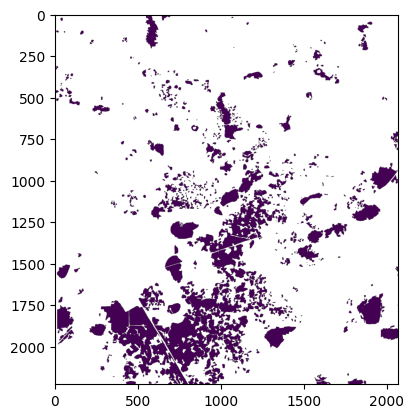

In [7]:
import matplotlib.pyplot as plt
mask_arry2 = new_mask.to_array().to_numpy().squeeze()
plt.imshow(mask_arry2)

In [1]:
import rioxarray
import xarray as xr
xr.backends.list_engines()

{'netcdf4': <NetCDF4BackendEntrypoint>
   Open netCDF (.nc, .nc4 and .cdf) and most HDF5 files using netCDF4 in Xarray
   Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.NetCDF4BackendEntrypoint.html,
 'scipy': <ScipyBackendEntrypoint>
   Open netCDF files (.nc, .nc4, .cdf and .gz) using scipy in Xarray
   Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.ScipyBackendEntrypoint.html,
 'kerchunk': <KerchunkBackend>
   Open Kerchunk References with Xarray
   Learn more at https://fsspec.github.io/kerchunk/,
 'rasterio': <RasterioBackend>,
 'store': <StoreBackendEntrypoint>
   Open AbstractDataStore instances in Xarray
   Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.StoreBackendEntrypoint.html,
 'zarr': <ZarrBackendEntrypoint>
   Open zarr files (.zarr) using zarr in Xarray
   Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.ZarrBackendEntrypoint.html}